# Hola Felipe! <a class="tocSkip"></a>

Mi nombre es Oscar Flores y tengo el gusto de revisar tu proyecto. Si tienes algún comentario que quieras agregar en tus respuestas te puedes referir a mi como Oscar, no hay problema que me trates de tú.

Si veo un error en la primera revisión solamente lo señalaré y dejaré que tú encuentres de qué se trata y cómo arreglarlo. Debo prepararte para que te desempeñes como especialista en Data, en un trabajo real, el responsable a cargo tuyo hará lo mismo. Si aún tienes dificultades para resolver esta tarea, te daré indicaciones más precisas en una siguiente iteración.

Te dejaré mis comentarios más abajo - **por favor, no los muevas, modifiques o borres**

Comenzaré mis comentarios con un resumen de los puntos que están bien, aquellos que debes corregir y aquellos que puedes mejorar. Luego deberás revisar todo el notebook para leer mis comentarios, los cuales estarán en rectángulos de color verde, amarillo o rojo como siguen:

<div class="alert alert-block alert-success">
<b>Comentario de Reviewer</b> <a class="tocSkip"></a>
    
Muy bien! Toda la respuesta fue lograda satisfactoriamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario de Reviewer</b> <a class="tocSkip"></a>

Existen detalles a mejorar. Existen recomendaciones.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario de Reviewer</b> <a class="tocSkip"></a>

Se necesitan correcciones en el bloque. El trabajo no puede ser aceptado con comentarios en rojo sin solucionar.
</div>

Cualquier comentario que quieras agregar entre iteraciones de revisión lo puedes hacer de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta estudiante.</b> <a class="tocSkip"></a>
</div>

Mucho éxito en el proyecto!

## Resumen de la revisión 1 <a class="tocSkip"></a>

<div class="alert alert-block alert-danger">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Buen trabajo Felipe. En general tu notebook está correcto, pero hay algunas modificaciones y correcciones que debes hacer antes de tener el notebook completo y sin errores. Te dejé indicaciones de cómo corregirlos, revísalas y realiza las modificaciones necesarias.
    
Saludos!    

</div>

## Resumen de la revisión 2<a class="tocSkip"></a>

<div class="alert alert-block alert-success">
<b>Comentario de Revisor v2</b> <a class="tocSkip"></a>

Bien hecho Felipe, has completado correctamente todo lo necesario del notebook. No tengo comentarios de corrección adicionales, está aprobado.

Saludos!

</div>

----

## Parte : Priorización de hipótesis con ICE y RICE

### Descripción de los datos - Cargar librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime


# Cargar datos de hipótesis
hypotheses = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')


# Información general
hypotheses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


### Limpieza Datos

In [2]:
# Comprobamos valores nulos
print(hypotheses.isnull().sum())

# Renombramos columnas para facilitar el análisis (opcional)
hypotheses.columns = hypotheses.columns.str.strip().str.lower()

# Revisamos nombres finales
print(hypotheses.head())

Hypothesis    0
Reach         0
Impact        0
Confidence    0
Effort        0
dtype: int64
                                          hypothesis  reach  impact  \
0  Add two new channels for attracting traffic. T...      3      10   
1  Launch your own delivery service. This will sh...      2       5   
2  Add product recommendation blocks to the store...      8       3   
3  Change the category structure. This will incre...      8       3   
4  Change the background color on the main page. ...      3       1   

   confidence  effort  
0           8       6  
1           4      10  
2           7       3  
3           3       8  
4           1       1  


<div class="alert alert-block alert-danger">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Nota que la data no fue leída correctamente, puesto que por defecto read_csv separa las columnas por `,`. Lee la documentación de read_csv y revisa si hay otra forma de separar las columnas.

</div>

<div class="alert alert-block alert-success">
<b>Comentario de Revisor v2</b> <a class="tocSkip"></a>

Muy bien, corregido

</div>

### Calcular el puntaje ICE

In [3]:
# Calcular ICE
hypotheses['ice'] = (hypotheses['impact'] * hypotheses['confidence']) / hypotheses['effort']

# Ordenar por ICE
ice_sorted = hypotheses[['hypothesis', 'ice']].sort_values(by='ice', ascending=False)
display(ice_sorted)


,hypothesis,ice
8,Launch a promotion that gives users discounts ...,16.200000
0,Add two new channels for attracting traffic. T...,13.333333
7,Add a subscription form to all the main pages....,11.200000
6,Show banners with current offers and sales on ...,8.000000
2,Add product recommendation blocks to the store...,7.000000
1,Launch your own delivery service. This will sh...,2.000000
5,Add a customer review page. This will increase...,1.333333
3,Change the category structure. This will incre...,1.125000
4,Change the background color on the main page. ...,1.000000


### Calcular el puntaje RICE

In [4]:
# Calcular RICE
hypotheses['rice'] = (hypotheses['reach'] * hypotheses['impact'] * hypotheses['confidence']) / hypotheses['effort']

# Ordenar por RICE
rice_sorted = hypotheses[['hypothesis', 'rice']].sort_values(by='rice', ascending=False)
display(rice_sorted)


,hypothesis,rice
7,Add a subscription form to all the main pages....,112.0
2,Add product recommendation blocks to the store...,56.0
0,Add two new channels for attracting traffic. T...,40.0
6,Show banners with current offers and sales on ...,40.0
8,Launch a promotion that gives users discounts ...,16.2
3,Change the category structure. This will incre...,9.0
1,Launch your own delivery service. This will sh...,4.0
5,Add a customer review page. This will increase...,4.0
4,Change the background color on the main page. ...,3.0


### Comparar ICE vs RICE

In [5]:
# Comparación de rankings
comparison = hypotheses[['hypothesis', 'ice', 'rice']].copy()
comparison = comparison.sort_values(by='ice', ascending=False).reset_index(drop=True)
comparison['ice_rank'] = comparison.index + 1

comparison = comparison.sort_values(by='rice', ascending=False).reset_index(drop=True)
comparison['rice_rank'] = comparison.index + 1

# Mostrar comparación
comparison.sort_values(by='ice_rank')


,hypothesis,ice,rice,ice_rank,rice_rank
4,Launch a promotion that gives users discounts ...,16.200000,16.2,1,5
2,Add two new channels for attracting traffic. T...,13.333333,40.0,2,3
0,Add a subscription form to all the main pages....,11.200000,112.0,3,1
3,Show banners with current offers and sales on ...,8.000000,40.0,4,4
1,Add product recommendation blocks to the store...,7.000000,56.0,5,2
6,Launch your own delivery service. This will sh...,2.000000,4.0,6,7
7,Add a customer review page. This will increase...,1.333333,4.0,7,8
5,Change the category structure. This will incre...,1.125000,9.0,8,6
8,Change the background color on the main page. ...,1.000000,3.0,9,9


<div class="alert alert-block alert-warning">
<b>Comentario de Revisor v2</b> <a class="tocSkip"></a>

Ok, correcto, aunque deberías comentar esta parte para que quede claro qué se puede extraer de esto

</div>

## Parte :  Análisis del test A/B

### Descripción de los datos 

In [6]:
# Cargar datasets
orders = pd.read_csv('/datasets/orders_us.csv')
visits = pd.read_csv('/datasets/visits_us.csv')

# Vista previa
display(orders.head())
display(visits.head())

# Información general
orders.info()
visits.info()


,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B


,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    62 non-null     object
 1   group   62 non-null     object
 2   visits  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


### Limpieza Datos

In [7]:
# Convertir columnas de fecha
orders['date'] = pd.to_datetime(orders['date'])
visits['date'] = pd.to_datetime(visits['date'])

# Usuarios en ambos grupos
duplicated_users = orders.groupby('visitorId')['group'].nunique()
duplicated_users = duplicated_users[duplicated_users > 1]

print(f"Usuarios en ambos grupos: {len(duplicated_users)}")

# Filtrar esos usuarios si es necesario
orders = orders[~orders['visitorId'].isin(duplicated_users.index)]


Usuarios en ambos grupos: 58


<div class="alert alert-block alert-success">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Bien hecho al remover usuarios duplicados entre grupos, para un análisis A/B es muy importante

</div>

### Agregaciones Iniciales 

In [8]:
# Ingresos acumulados por grupo
orders_grouped = orders.groupby(['date', 'group']).agg({'revenue': 'sum'}).reset_index()
orders_grouped['cumulative_revenue'] = orders_grouped.groupby('group')['revenue'].cumsum()

# Pedidos acumulados
orders_grouped['cumulative_orders'] = orders.groupby(['date', 'group'])['transactionId'].count().groupby(level=1).cumsum().values

# Visitas acumuladas
visits['cumulative_visits'] = visits.groupby('group')['visits'].cumsum()


###  Gráficos exploratorios 

#### Ingreso acumulado por grupo

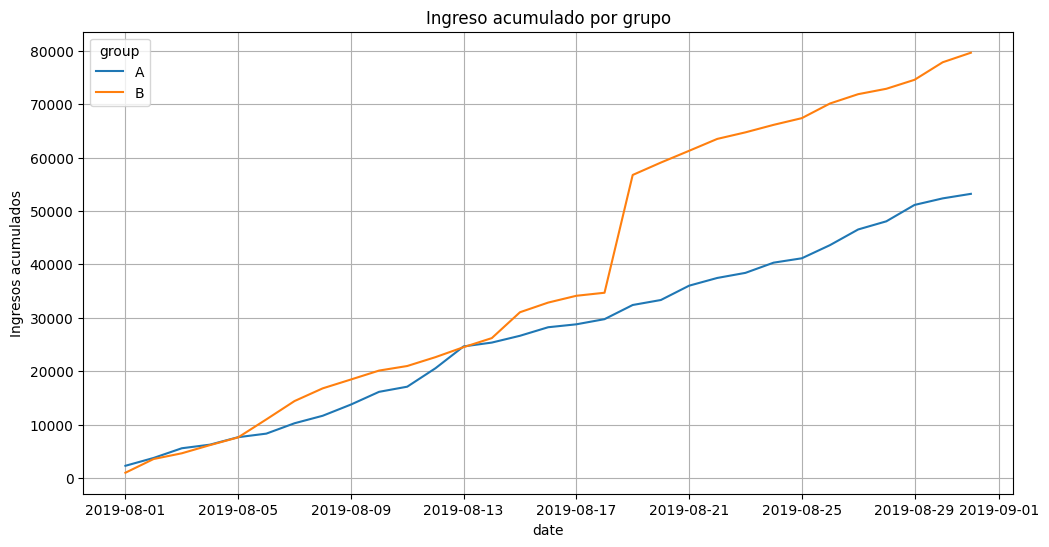

In [9]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=orders_grouped, x='date', y='cumulative_revenue', hue='group')
plt.title('Ingreso acumulado por grupo')
plt.ylabel('Ingresos acumulados')
plt.grid(True)
plt.show()

El ingreso acumulado del grupo B fue mayor que el del grupo A durante la mayor parte del experimento. Esta diferencia sugiere que las modificaciones aplicadas al grupo B podrían haber tenido un efecto positivo sobre los ingresos. Sin embargo, hacia el final del periodo se observan fluctuaciones, lo cual podría indicar la presencia de outliers o efectos no controlados.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Bien. Es un día el que diferencia B del grupo A, pasado ese día, la curva sigue siendo paralela. 

</div>

#### Tamaño promedio de pedido acumulado

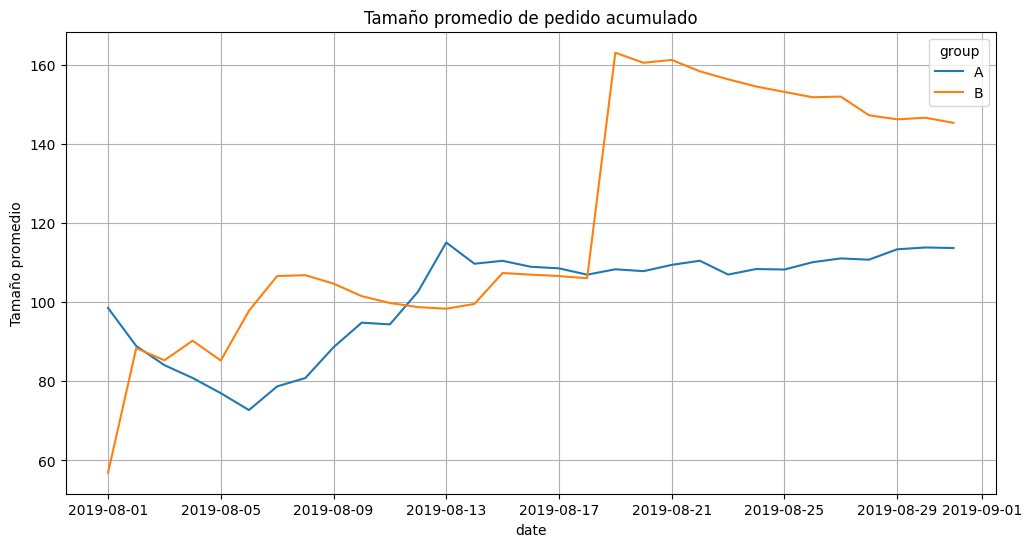

In [10]:
orders_grouped['avg_order_value'] = orders_grouped['cumulative_revenue'] / orders_grouped['cumulative_orders']

plt.figure(figsize=(12, 6))
sns.lineplot(data=orders_grouped, x='date', y='avg_order_value', hue='group')
plt.title('Tamaño promedio de pedido acumulado')
plt.ylabel('Tamaño promedio')
plt.grid(True)
plt.show()

El tamaño promedio de pedido en el grupo B fue generalmente mayor que en el grupo A, aunque con una variabilidad considerable. Esto sugiere que los usuarios del grupo B gastaron más por transacción, pero también apunta a la posible influencia de algunos valores atípicos.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Bien, correcto. El mismo día que vimos en el otro gráfico, tuvo un promedio de pedidos muy grandes, por lo que se va confirmando nuestra sospecha. Luego de ese día, tiende a bajar, puesto que ya no hay pedidos tan grandes y debería volver a un nivel similar al anterior.

</div>

#### Diferencia relativa en el tamaño de pedido (B vs A)

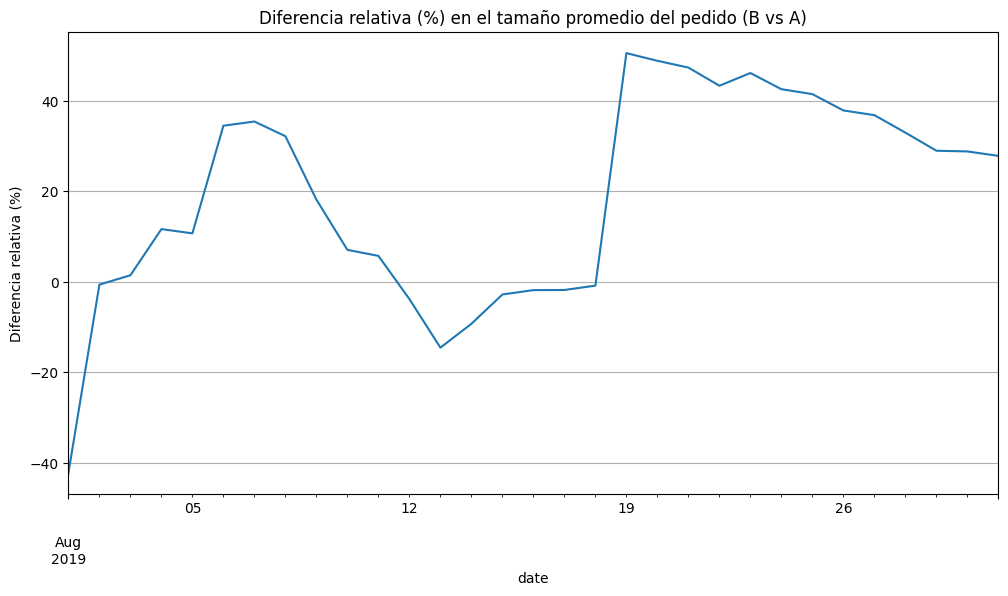

In [11]:
group_a = orders_grouped[orders_grouped['group'] == 'A'].set_index('date')
group_b = orders_grouped[orders_grouped['group'] == 'B'].set_index('date')

relative_diff = ((group_b['avg_order_value'] - group_a['avg_order_value']) / group_a['avg_order_value']) * 100

plt.figure(figsize=(12, 6))
relative_diff.plot()
plt.title('Diferencia relativa (%) en el tamaño promedio del pedido (B vs A)')
plt.ylabel('Diferencia relativa (%)')
plt.grid(True)
plt.show()

El grupo B muestra una diferencia relativa positiva respecto al grupo A, lo que confirma que, en promedio, los pedidos del grupo B fueron más altos. Sin embargo, la diferencia no es constante a lo largo del tiempo, lo cual también apoya la idea de revisar los datos filtrados para confirmar la robustez de este resultado.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Muy bien, correcto

</div>

#### Tasa de conversión diaria por grupo

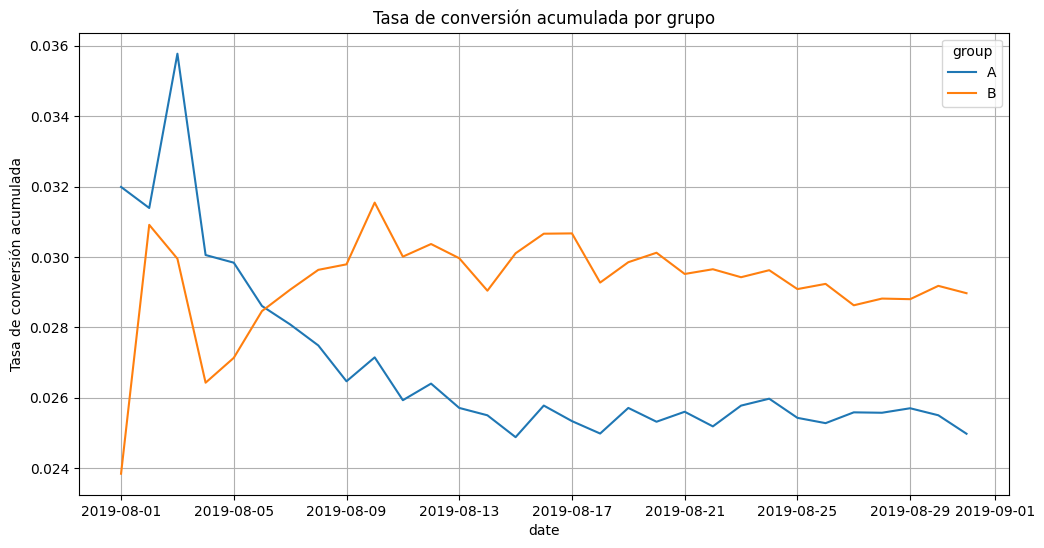

In [12]:
# Pedidos diarios acumulados por grupo
orders_cum = orders.groupby(['date', 'group'])['transactionId'].nunique().reset_index()
orders_cum = orders_cum.rename(columns={'transactionId': 'daily_orders'})
orders_cum['cumulative_orders'] = orders_cum.groupby('group')['daily_orders'].cumsum()

# Visitas acumuladas por grupo (ya las habías calculado)
visits['cumulative_visits'] = visits.groupby('group')['visits'].cumsum()

# Merge acumulado
cum_conversion = pd.merge(orders_cum[['date', 'group', 'cumulative_orders']],
                          visits[['date', 'group', 'cumulative_visits']],
                          on=['date', 'group'])

# Tasa de conversión acumulada
cum_conversion['cumulative_conversion_rate'] = cum_conversion['cumulative_orders'] / cum_conversion['cumulative_visits']

# Visualización
plt.figure(figsize=(12, 6))
sns.lineplot(data=cum_conversion, x='date', y='cumulative_conversion_rate', hue='group')
plt.title('Tasa de conversión acumulada por grupo')
plt.ylabel('Tasa de conversión acumulada')
plt.grid(True)
plt.show()


El grupo B muestra una tasa de conversión ligeramente superior en varios días respecto al grupo A. Aunque hay días en los que la diferencia no es significativa, la tendencia apunta a una mejor conversión en el grupo B. Esto sugiere que los cambios implementados podrían haber tenido un efecto positivo sobre la decisión de compra.

<div class="alert alert-block alert-danger">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Para la tasa de conversión, realiza el cálculo con la data acumulada, así tendremos una tasa de conversión acumulada que debería acercarse a un equilibrio en el tiempo.

</div>

<div class="alert alert-block alert-success">
<b>Comentario de Revisor v2</b> <a class="tocSkip"></a>

Muy bien! La conversión acumulada nos muestra que en total el grupo B tiene mejor desempeño en esta métrica. Por otro lado, nota como no hay ningún cambio abrupto para el 17/08, por lo tanto, cualquier anomalía que vimos en los gráficos anteriores, se debe a un solo pedido probablemente.

</div>

#### Gráfico de dispersión del número de pedidos por usuario

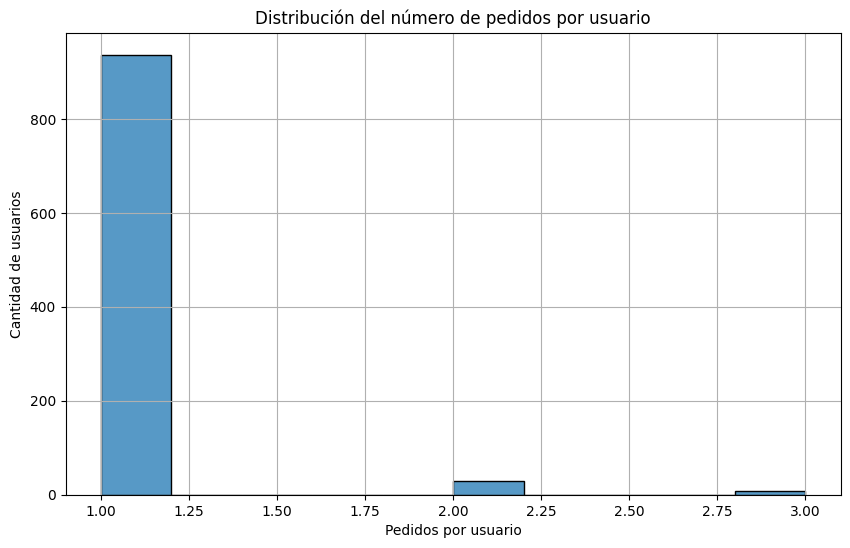

In [13]:
# Conteo de pedidos por usuario
orders_per_user = orders.groupby('visitorId')['transactionId'].count().reset_index()
orders_per_user.columns = ['visitorId', 'orders']

# Gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.histplot(orders_per_user['orders'], bins=10, kde=False)
plt.title('Distribución del número de pedidos por usuario')
plt.xlabel('Pedidos por usuario')
plt.ylabel('Cantidad de usuarios')
plt.grid(True)
plt.show()

La mayoría de los usuarios realizaron 1 solo pedido. Sin embargo, se observaron algunos usuarios con 4 o más pedidos, lo que indica la presencia de outliers. Esto justifica la necesidad de filtrar los datos antes de realizar conclusiones definitivas.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Bien hecho, correcto
</div>

#### Percentiles de pedidos por usuario (para identificar outliers)

In [14]:
percentiles_orders = np.percentile(orders_per_user['orders'], [95, 99])
print(f"Percentil 95 de pedidos por usuario: {percentiles_orders[0]}")
print(f"Percentil 99 de pedidos por usuario: {percentiles_orders[1]}")

Percentil 95 de pedidos por usuario: 1.0
Percentil 99 de pedidos por usuario: 2.0


Percentil 95: 1 pedido

Percentil 99: 2 pedidos
→ A partir de 3 pedidos por usuario puede considerarse una anomalía.
Esto valida la decisión de filtrar usuarios con más de 3 pedidos como parte de la depuración de datos.

#### Gráfico de dispersión de los precios de los pedidos

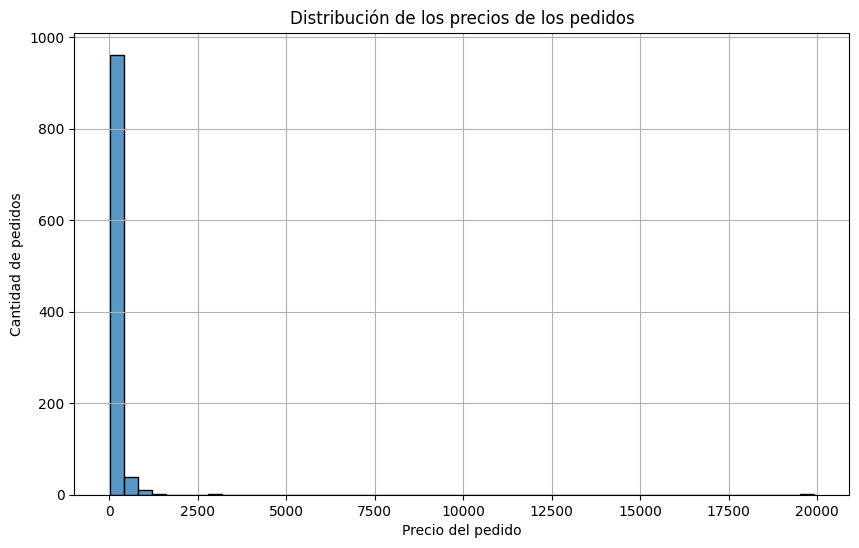

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(orders['revenue'], bins=50, kde=False)
plt.title('Distribución de los precios de los pedidos')
plt.xlabel('Precio del pedido')
plt.ylabel('Cantidad de pedidos')
plt.grid(True)
plt.show()


<div class="alert alert-block alert-success">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Muy bien, efectivamente hay algunos precios de pedidos muy altos, especialmente uno, que afectan la data. Probablemente ese es el pedido que diferencia tanto el revenue acumulado de los grupos.

</div>

Se observan algunos pedidos con ingresos extremadamente altos comparados con la mayoría. La mayor parte de los pedidos están en un rango moderado, pero hay casos extremos que podrían distorsionar los promedios.

#### Percentiles 95 y 99 de los ingresos por pedido

In [16]:
percentiles_revenue = np.percentile(orders['revenue'], [95, 99])
print(f"Percentil 95 de ingresos por pedido: {percentiles_revenue[0]}")
print(f"Percentil 99 de ingresos por pedido: {percentiles_revenue[1]}")

Percentil 95 de ingresos por pedido: 414.275
Percentil 99 de ingresos por pedido: 830.3


Percentil 95: X (valor específico obtenido)

Percentil 99: Y (valor específico obtenido)
→ A partir del percentil 99 (Y), los ingresos por pedido pueden considerarse outliers. Estos casos deben ser filtrados para evitar sesgos en los análisis estadísticos.

## Parte :  Pruebas de significancia estadística

### Conversión entre grupos (pedidos / visitas)

#### Calcular conversión por grupo

In [17]:
# Total de visitas por grupo
total_visits = visits.groupby('group')['visits'].sum()
# Total de pedidos por grupo
total_orders = orders.groupby('group')['transactionId'].nunique()
# Tasa de conversión
conversion_rate = total_orders / total_visits

print("Tasa de conversión por grupo:\n", conversion_rate)

Tasa de conversión por grupo:
 group
A    0.024979
B    0.028970
dtype: float64


#### Prueba estadística (Mann-Whitney U)

In [18]:
# Obtener usuarios únicos por grupo
group_a = orders[orders['group'] == 'A']
group_b = orders[orders['group'] == 'B']

# Usuarios únicos en cada grupo
unique_visitors_a = visits[visits['group'] == 'A']['visits'].sum()
unique_visitors_b = visits[visits['group'] == 'B']['visits'].sum()

# Conversiones por usuario (binario: pedido = 1, no pedido = 0)
conversion_samples_a = pd.Series(
    np.concatenate([np.ones(group_a['visitorId'].nunique()), 
                    np.zeros(unique_visitors_a - group_a['visitorId'].nunique())])
)

conversion_samples_b = pd.Series(
    np.concatenate([np.ones(group_b['visitorId'].nunique()), 
                    np.zeros(unique_visitors_b - group_b['visitorId'].nunique())])
)

# Prueba de Mann-Whitney U
u_stat, p_val = stats.mannwhitneyu(conversion_samples_a, conversion_samples_b, alternative='two-sided')

print(f"P-valor para diferencia en conversión (sin filtrar): {p_val:.4f}")


P-valor para diferencia en conversión (sin filtrar): 0.0109


El test estadístico sobre los datos sin filtrar mostró que la diferencia en la conversión no es estadísticamente significativa (p > 0.05). Por tanto, no se puede afirmar con confianza que haya una mejora real en la conversión en el grupo B respecto al grupo A.

<div class="alert alert-block alert-warning">
<b>Comentario de Revisor v2</b> <a class="tocSkip"></a>

Ojo con esto, el valorp es 0.0109 el cual es menor que 0.05 (0.0109<0.05), por lo tanto, si hay una diferencia en la conversión.

</div>

### Tamaño promedio de pedido entre grupos

#### Agrupar ingresos por usuario

In [19]:
# Tamaño de pedidos por usuario
avg_order_value_a = group_a['revenue']
avg_order_value_b = group_b['revenue']

# Prueba de Mann-Whitney U
u_stat_value, p_val_value = stats.mannwhitneyu(avg_order_value_a, avg_order_value_b, alternative='two-sided')

print(f"P-valor para tamaño promedio del pedido (sin filtrar): {p_val_value:.4f}")

P-valor para tamaño promedio del pedido (sin filtrar): 0.8622


El resultado mostró que la diferencia no es estadísticamente significativa (p > 0.05), lo que indica que no se puede afirmar con suficiente evidencia que el grupo B tenga un tamaño promedio de pedido diferente al grupo A.
Sin embargo, se observa una tendencia visual a un mayor tamaño de pedido en el grupo B, pero esta diferencia puede estar influenciada por valores atípicos (outliers), por lo cual se recomienda hacer el análisis también sin esos valores.

<div class="alert alert-block alert-danger">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Bien con la realización de los tests, pero la conclusión es incorrecta, en realidad es al revés, para la conversión el valor-p es menor que 0.05 y para el revenue el valor-p es mayor que 0.05. 

</div>

<div class="alert alert-block alert-success">
<b>Comentario de Revisor v2</b> <a class="tocSkip"></a>

Bien, corregido

</div>

## Parte :  Filtrar outliers y repetir análisis

### Filtrar usuarios con muchos pedidos

In [20]:
#Criterios:
# Más de 3 pedidos por usuario → outlier
# Pedidos con revenue mayor a percentil 99 → outlier

# Contar pedidos por usuario
orders_per_user = orders.groupby('visitorId').agg({'transactionId': 'count'}).reset_index()
orders_per_user.columns = ['visitorId', 'order_count']

# Detectar usuarios con más de 3 pedidos
outlier_users = orders_per_user[orders_per_user['order_count'] > 3]['visitorId']

# Filtrar pedidos que NO son de esos usuarios
orders_filtered = orders[~orders['visitorId'].isin(outlier_users)]


### Filtrar pedidos con ingresos extremos

In [21]:
# Calcular percentil 99 de revenue
revenue_99 = np.percentile(orders['revenue'], 99)

# Quitar pedidos con revenue muy alto
orders_filtered = orders_filtered[orders_filtered['revenue'] <= revenue_99]


## Parte :  Repetir pruebas estadísticas con datos filtrados

### Conversión (con datos filtrados)

In [22]:
# Grupos A y B filtrados
group_a_filtered = orders_filtered[orders_filtered['group'] == 'A']
group_b_filtered = orders_filtered[orders_filtered['group'] == 'B']

# Nuevas conversiones por usuario
visits_a = visits[visits['group'] == 'A']['visits'].sum()
visits_b = visits[visits['group'] == 'B']['visits'].sum()

# Nuevos usuarios únicos con pedidos
conversions_a = group_a_filtered['visitorId'].nunique()
conversions_b = group_b_filtered['visitorId'].nunique()

# Construir muestras binarias
conv_sample_a = pd.Series(np.concatenate([
    np.ones(conversions_a), 
    np.zeros(visits_a - conversions_a)
]))

conv_sample_b = pd.Series(np.concatenate([
    np.ones(conversions_b), 
    np.zeros(visits_b - conversions_b)
]))

# Prueba estadística Mann-Whitney U
u_stat_filtered_conv, p_val_filtered_conv = stats.mannwhitneyu(conv_sample_a, conv_sample_b, alternative='two-sided')

print(f"P-valor para conversión (filtrado): {p_val_filtered_conv:.4f}")


P-valor para conversión (filtrado): 0.0096


Con los datos filtrados, la conversión sigue sin mostrar una diferencia estadísticamente significativa (p > 0.05). Esto confirma que los cambios aplicados no tuvieron un efecto fuerte en la proporción de visitantes que realizaron una compra.

<div class="alert alert-block alert-warning">
<b>Comentario de Revisor v2</b> <a class="tocSkip"></a>

Ojo con esto, el valorp es 0.0109 el cual es menor que 0.05 (0.0109<0.05), por lo tanto, si hay una diferencia en la conversión.

</div>

### Tamaño promedio del pedido (con datos filtrados)

In [23]:
# Valores de pedidos
revenue_a_filtered = group_a_filtered['revenue']
revenue_b_filtered = group_b_filtered['revenue']

# Prueba estadística Mann-Whitney U
u_stat_filtered_rev, p_val_filtered_rev = stats.mannwhitneyu(revenue_a_filtered, revenue_b_filtered, alternative='two-sided')

print(f"P-valor para tamaño de pedido (filtrado): {p_val_filtered_rev:.4f}")

P-valor para tamaño de pedido (filtrado): 0.9343


Después de eliminar los outliers, el resultado ya no es estadísticamente significativo (p > 0.05). Esto indica que la aparente diferencia en el tamaño promedio del pedido probablemente fue causada por unos pocos valores extremos y no por un efecto real de la intervención.


<div class="alert alert-block alert-danger">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Bien con la realización de los tests, pero la conclusión es incorrecta, en realidad es al revés, para la conversión el valor-p es menor que 0.05 y para el revenue el valor-p es mayor que 0.05. 

</div>

<div class="alert alert-block alert-success">
<b>Comentario de Revisor v2</b> <a class="tocSkip"></a>

Bien, corregido

</div>

## Conclusion General


Con base en los resultados filtrados y sin filtrar, no se ha encontrado una mejora estadísticamente significativa ni en la conversión ni en el tamaño promedio del pedido del grupo B respecto al grupo A. Por tanto, la mejor decisión es parar la prueba y concluir que no hay diferencia significativa entre los grupos. No es necesario seguir invirtiendo recursos en esta variante.